In [26]:
from dotenv import load_dotenv

load_dotenv()

True

In [27]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [28]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage # HumanMessage, AIMessage, SystemMessage, ToolMessage, FunctionMessage를 나타내는 추상화된 타입

# 상태 정의
class State(TypedDict):	
    messages: Annotated[AnyMessage, add_messages] # add_messages 리듀서 함수는 상태 키의 값(메시지)을 업데이트(덮어쓰는 대신 리스트에 추가)

In [29]:
from langgraph.graph import StateGraph

# 그래프 생성
graph_builder = StateGraph(State)

In [30]:
def generate(state: State):
    return {"messages": [model.invoke(state["messages"])]}

graph_builder.add_node("generate", generate)

In [31]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

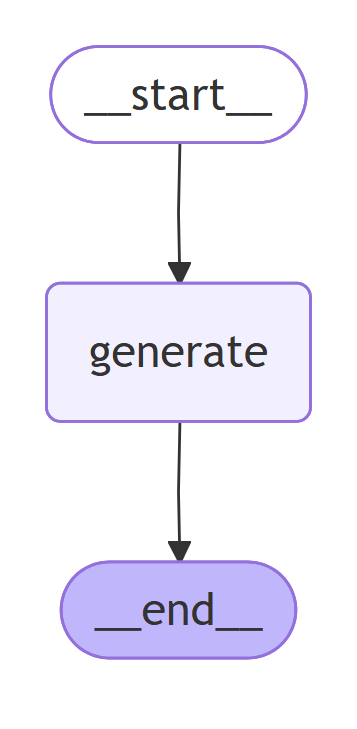

In [ ]:
# [venv 경로]\Lib\site-packages\langchain_core\runnables\graph_mermaid.py
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [33]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [34]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages":  [HumanMessage("내 이름은 김일남이야")]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='내 이름은 김일남이야', additional_kwargs={}, response_metadata={}, id='813eaf8b-04e4-474b-99d7-355f2544a7cb'),
  AIMessage(content='안녕하세요, 김일남님. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--618d707d-7c98-426c-a668-8fdf9caf3b52-0', usage_metadata={'input_tokens': 8, 'output_tokens': 20, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}})]}

In [35]:
response["messages"].append("내 이름은?") # 딕셔너리에 새 메시지를 직접 추가(멀티턴 아님)
graph.invoke(response)

{'messages': [HumanMessage(content='내 이름은 김일남이야', additional_kwargs={}, response_metadata={}, id='813eaf8b-04e4-474b-99d7-355f2544a7cb'),
  AIMessage(content='안녕하세요, 김일남님. 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--618d707d-7c98-426c-a668-8fdf9caf3b52-0', usage_metadata={'input_tokens': 8, 'output_tokens': 20, 'total_tokens': 28, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='내 이름은?', additional_kwargs={}, response_metadata={}, id='8372d338-94ba-4320-bd47-27d7d259c810'),
  AIMessage(content='김일남님.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--471d995f-3a3c-408a-a426-6e38654cb36e-0', usage_metadata={'input_tokens': 31, 'output_tokens': 6, 'total_tokens': 37

✨ 대화 기억하지 않음

In [36]:
from langchain.schema import HumanMessage

while True:
    user_input = input("You\t:")
    
    if user_input in ["exit", "quit", "q"]:
        break

    for event in graph.stream({"messages": [HumanMessage(user_input)]}, stream_mode="values"):

        # print("event>>>", event)

        # HumanMessage와 AIMessage를 포함한 모든 LangChain 메시지 클래스는 BaseMessage 클래스를 상속받는다.
        # BaseMessage 클래스는 pretty_print() 메서드를 내장하고 있다.
        event["messages"][-1].pretty_print()

    print(f'\n(현재 메시지 개수: {len(event["messages"])})\n')

================================ Human Message =================================

내 이름은 김일남이야
================================== Ai Message ==================================

안녕하세요, 김일남 님. 만나서 반갑습니다. 무엇을 도와드릴까요?

(현재 메시지 개수: 2)

================================ Human Message =================================

내 이름은 뭐지?
================================== Ai Message ==================================

저는 인공지능 모델이므로 이름이 없습니다. 저는 사용자와 대화하고 정보를 제공하기 위해 만들어졌습니다.

(현재 메시지 개수: 2)

